<h1 style="font-size: 0; line-height: 0; height: 0; margin: 0; padding: 0;">&#8203;</h1>
<center><img align="center" src="https://www.sydney.edu.au/content/dam/icons/logos/logo-usyd-dark.svg"></center>
<h1 align="center" style="margin-top:10px">QBUS3830 Advanced Analytics</h1>
<h2 align="center" style="margin-top:20px">Week 1 Tutorial: From Predictions to Decisions</h2>
<br>

You are a credit risk analyst deciding which loan applications to approve. You will build a decision framework from a payoff matrix, estimate default probabilities, and turn those probabilities into approve/reject decisions with a measurable business value.

### What this tutorial is for

The lecture argued that **prediction is the foundational layer** this unit builds on. This tutorial is a refresher on the full arc of predictive analytics, from business framing and data, through representation and estimation, to decisions and evaluation.

Concretely, you will:

* Construct a payoff matrix and derive a decision threshold from business economics.
* Apply the threshold to convert predicted probabilities into approve/reject decisions.
* Move up the lecture's *"improving the predictions"* ladder: from standard logistic regression, to regularised logistic regression, to a tabular foundation model (TabPFN-3).
* Evaluate the models with **decision loss** and standard metrics, and estimate the business value of the system relative to a baseline.

Prediction is treated as assumed background here, so the estimation section stays deliberately light. The emphasis is on the reasoning that turns an estimate into a decision, which is the subject of the whole unit.

### Getting things ready

Run the cells below to import packages and configure plots.


In [3]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch

print(f'Package versions:\n')
print(f'numpy {np.__version__}')
print(f'scipy {scipy.__version__}')
print(f'pandas {pd.__version__}')
print(f'seaborn {sns.__version__}')
print(f'scikit-learn {sklearn.__version__}')
print(f'torch {torch.__version__}')


Package versions:

numpy 2.5.1
scipy 1.18.0
pandas 3.0.5
seaborn 0.13.2
scikit-learn 1.9.0
torch 2.13.0+cpu


In [4]:
import warnings
warnings.filterwarnings('ignore')

# Plot settings
sns.set_context('notebook')
sns.set_style('ticks')
colours = ['#4E79A7','#F28E2C','#E15759','#76B7B2','#59A14F',
          '#EDC949','#AF7AA1','#FF9DA7','#9C755F','#BAB0AB']
sns.set_palette(colours)

%matplotlib inline
plt.rcParams['figure.figsize'] = (9, 6)
plt.rcParams['figure.dpi'] = 80
%config InlineBackend.figure_format = 'retina'

# 1. Business problem and decision framework

**Question: How do banks decide who gets a loan?**

Before we dive into coding, let's think about the real-world business problem we are solving.

Imagine you are a credit risk analyst at a major bank. Your goal is to predict whether a customer will default on a loan. This decision has significant financial implications:

* Approve a creditworthy customer and the bank earns interest revenue.
* Approve a risky customer and the bank may lose money if they default.
* Reject a creditworthy customer and the bank misses out on profit.

**Key question:** How can we use data to make loan approval decisions in a principled, repeatable way?

## 1.1 Payoff matrix

In the lecture, we saw that the starting point for decision analysis is the payoff matrix: the economic consequence of each action under each possible outcome.

For this tutorial, we will use hypothetical dollar values for the payoff matrix. These values are chosen to be consistent with the loss ratio suggested in the dataset documentation, which states that approving a customer who later defaults is about 5 times worse than rejecting a customer who would have repaid. (The lecture's worked example used different dollar values and hence a different threshold; the recipe is identical, only the economics change.)

We assume:

<table>
  <tr>
   <th></th>
  <th>Action: Approve</th>
  <th>Action: Reject</th>
  </tr>
  <tr>
     <th>Outcome: Repays</th>
    <td>4,000</td>
    <td>2,000</td>
  </tr>
  <tr>
     <th>Outcome: Default</th>
    <td>-8,000</td>
    <td>2,000</td>
  </tr>
</table>

To keep the analysis simple, we use the same payoff values for every applicant. In reality, this is a simplification. The dataset includes the loan amount, so the financial consequences would usually differ across customers.

## 1.2 Loss Matrix

Given the payoff matrix, it is often convenient to work with a loss matrix, which focuses on the cost of each decision relative to the best action in each outcome.

This gives:

<table>
  <tr>
   <th></th>
  <th>Action: Approve</th>
  <th>Action: Reject</th>
  </tr>
  <tr>
     <th>Outcome: Repays</th>
    <td>0</td>
    <td>2,000</td>
  </tr>
  <tr>
     <th>Outcome: Default</th>
    <td>10,000</td>
    <td>0</td>
  </tr>
</table>

So the bank should be relatively conservative: approving a customer who defaults is much more costly than rejecting a customer who would have repaid.

## 1.3 Decision threshold

We calculate the decision threshold using the formula derived in the lecture. With $L_{\text{FP}} = 2,000$ and $L_{\text{FN}} = 10,000$:

$$\tau = \frac{L_{\text{FP}}}{L_{\text{FP}} + L_{\text{FN}}}$$

In [5]:
loss_fp = 2000  # Cost of rejecting a good borrower (relative)
loss_fn = 10000  # Cost of approving a defaulter (relative)

decision_threshold = loss_fp / (loss_fp + loss_fn)
print(f'Decision threshold: tau = {decision_threshold:.3f}')

Decision threshold: tau = 0.167


**Conclusion:** Decision theory tells us that we should approve the loan if the predicted probability of default is lower than 0.167. Applicants with predicted default probability above this threshold are too risky for the bank and should be rejected.

**Question:** If the bank had a manual review team, which applicants would you send for review rather than auto-approve or auto-reject?

# 2. Credit data

Before we fit anything, we need to understand the data it will learn from. We will work with the [German Credit Data](https://archive.ics.uci.edu/ml/datasets/Statlog+%28German+Credit+Data%29), which contains real-world loan applications with information about customers and whether they repaid or defaulted on their loans.

## 2.1 Loading the data

**Code: Loading the data**

In [7]:
data = pd.read_csv('Data/german_credit.csv')
data.head()

,status,duration,history,purpose,amount,savings,employment,installment_rate,personal,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,people_under_maintenance,telephone,foreign_worker,default
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,1,1,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,0,1,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,0,1,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,0,1,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,0,1,1


Each observation represents a loan application. The target column (`default`) records whether the customer defaulted (1) or repaid (0). The remaining columns are the features.

## 2.2 Taking a first look at the data

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   status                    1000 non-null   str  
 1   duration                  1000 non-null   int64
 2   history                   1000 non-null   str  
 3   purpose                   1000 non-null   str  
 4   amount                    1000 non-null   int64
 5   savings                   1000 non-null   str  
 6   employment                1000 non-null   str  
 7   installment_rate          1000 non-null   int64
 8   personal                  1000 non-null   str  
 9   other_debtors             1000 non-null   str  
 10  residence                 1000 non-null   int64
 11  property                  1000 non-null   str  
 12  age                       1000 non-null   int64
 13  other_installment_plans   1000 non-null   str  
 14  housing                   1000 non-null   str  
 15 

**Pause and think:** What can we learn about the data from this output?

## 2.3 Classifying the features

Some steps of the analysis treat different data types differently, so we classify our features manually based on inspecting the data and the [documentation](https://archive.ics.uci.edu/ml/datasets/Statlog+%28German+Credit+Data%29).

In [10]:
continuous = ['duration', 'amount', 'age']

discrete = ['installment_rate', 'residence', 'existing_credits', 'people_under_maintenance']

categorical = ['status', 'history', 'purpose', 'savings', 'employment', 'personal',
               'other_debtors', 'property', 'other_installment_plans', 'housing', 'job']

binary = ['telephone', 'foreign_worker']

target = ['default']

## 2.4 Splitting the data

Before training a model, we split the dataset into a training set and a validation set. The validation set lets us estimate how well the model will perform on new, unseen data.

**Code: Splitting the data**

In [11]:
from sklearn.model_selection import train_test_split

index_train, index_valid = train_test_split(
    np.array(data.index),
    stratify=data[target],  # Ensures same default rate in both sets
    train_size=0.7,
    random_state=5           # Ensures reproducibility
)

train = data.loc[index_train, :].copy()
valid = data.loc[index_valid, :].copy()

print(f'Training set: {len(train)} observations')
print(f'Validation set: {len(valid)} observations')

Training set: 700 observations
Validation set: 300 observations


# 3. Exploratory data analysis

Before modelling, we explore the data to understand distributions, detect patterns, and identify potential issues. With many features available, a key practical skill is knowing where to focus first.

## 3.1 Summary statistics

In [12]:
train.describe().round(2)

,duration,amount,installment_rate,residence,age,existing_credits,people_under_maintenance,telephone,foreign_worker,default
count,700.00,700.00,700.00,700.00,700.00,700.00,700.00,700.00,700.00,700.00
mean,21.12,3346.50,2.97,2.84,35.67,1.43,1.16,0.41,0.97,0.30
std,12.26,2870.26,1.13,1.11,11.60,0.59,0.37,0.49,0.18,0.46
min,4.00,250.00,1.00,1.00,20.00,1.00,1.00,0.00,0.00,0.00
25%,12.00,1364.00,2.00,2.00,27.00,1.00,1.00,0.00,1.00,0.00
50%,18.00,2339.50,3.00,3.00,33.00,1.00,1.00,0.00,1.00,0.00
75%,24.00,4151.50,4.00,4.00,42.00,2.00,1.00,1.00,1.00,1.00
max,60.00,15945.00,4.00,4.00,75.00,4.00,2.00,1.00,1.00,1.00


## 3.2 Default rate

**Question:** What is the default rate in this dataset?

In [13]:
train['default'].value_counts(normalize=True)

default
0    0.7
1    0.3
Name: proportion, dtype: float64

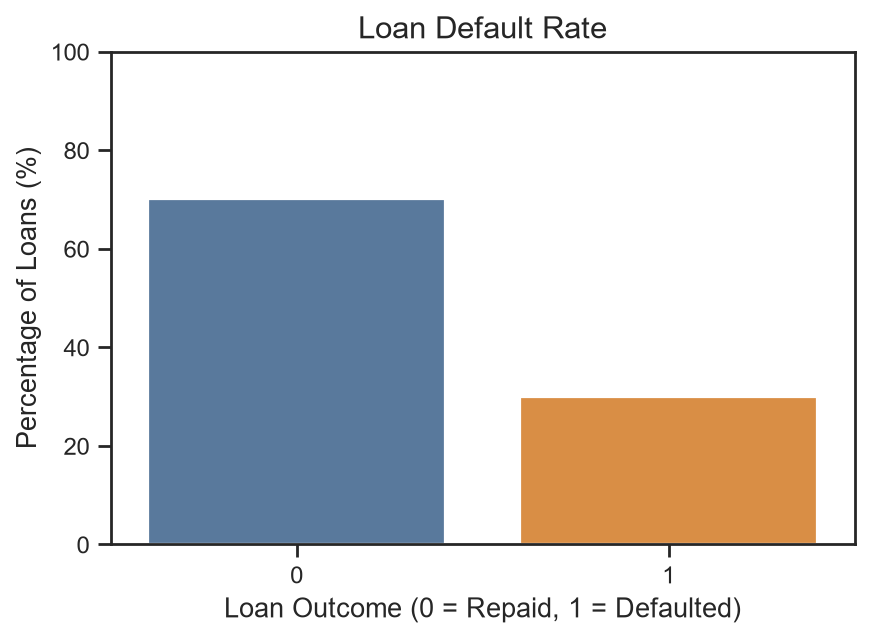

In [14]:
# skip_code

plt.figure(figsize=(6, 4))
sns.barplot(x=train['default'].value_counts().index,
            y=train['default'].value_counts(normalize=True) * 100,
            palette=colours[:2])

plt.title('Loan Default Rate', fontsize=14)
plt.ylabel('Percentage of Loans (%)')
plt.xlabel('Loan Outcome (0 = Repaid, 1 = Defaulted)')
plt.ylim(0, 100)
plt.show()

## 3.3 Which features matter most?

With many features available, it helps to **rank them by relevance** before doing detailed exploration. This way we focus our attention on the features most likely to be useful for prediction.

**Mutual information** (MI) measures how much knowing one variable reduces uncertainty about another. Unlike correlation, MI captures any type of statistical dependence, not just linear relationships. Higher MI means the feature is more informative about default risk.

In [15]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

# MI for continuous features
mi_cont = mutual_info_classif(train[continuous], train['default'], random_state=1)
mi_continuous = pd.DataFrame(mi_cont, index=continuous, columns=['MI'])

# MI for discrete and categorical features (requires integer encoding)
cat_features = discrete + categorical + binary
features_encoded = OrdinalEncoder().fit_transform(train[cat_features])
mi_cat = mutual_info_classif(features_encoded, train['default'],
                              n_neighbors=5, random_state=1, discrete_features=True)
mi_discrete = pd.DataFrame(mi_cat, index=cat_features, columns=['MI'])

# Combine and sort
mi_results = pd.concat([mi_continuous, mi_discrete]).sort_values('MI', ascending=True)

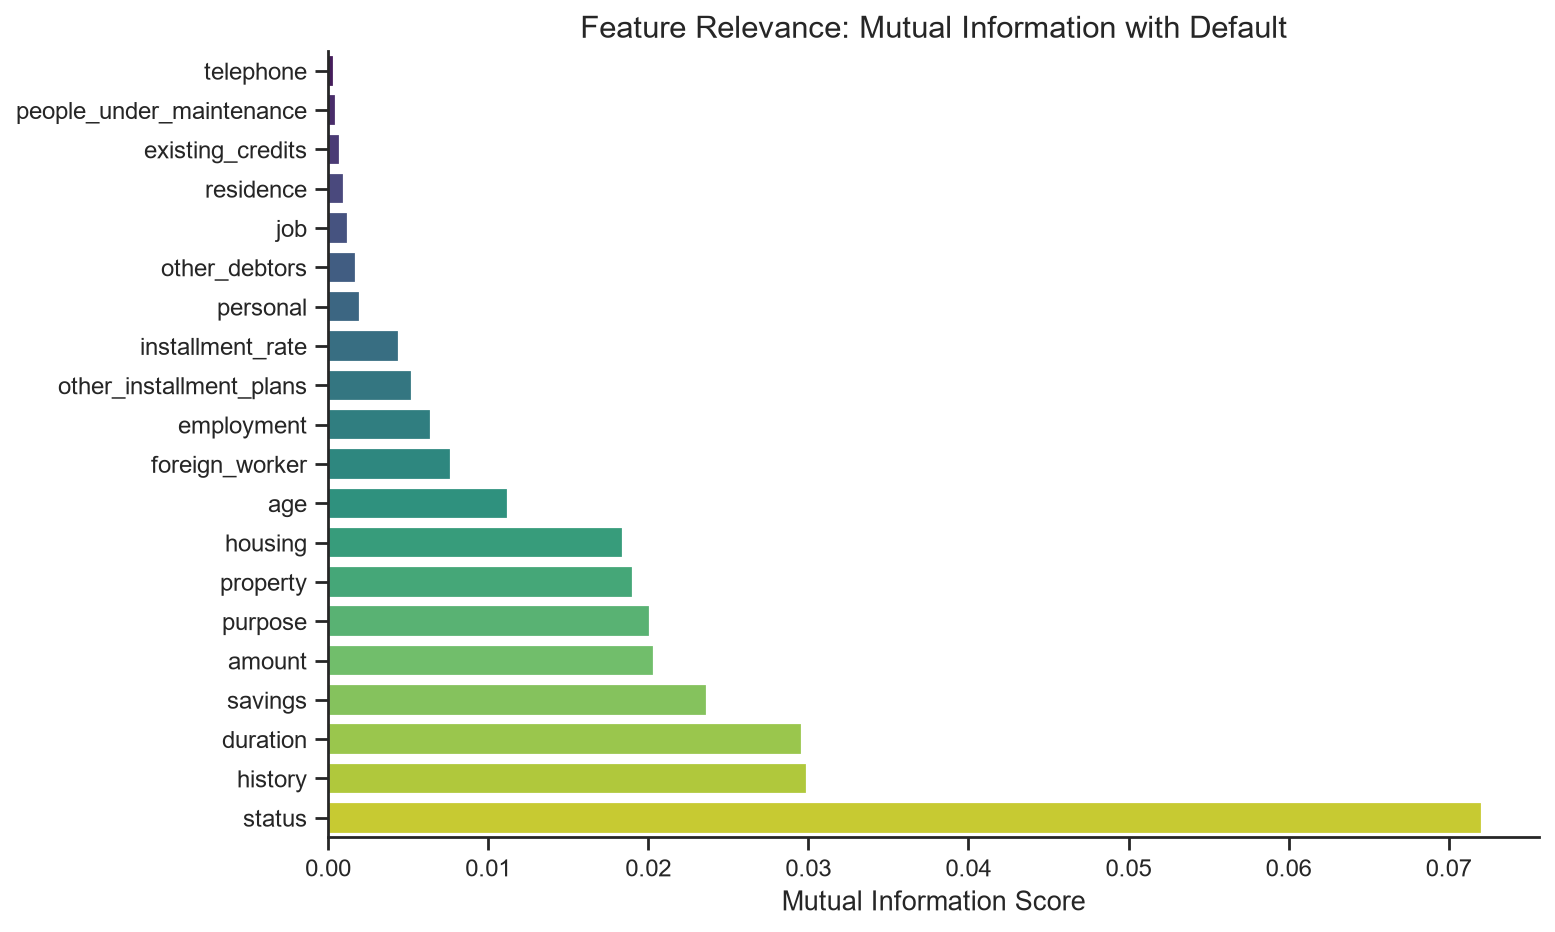

In [16]:
# 
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_results['MI'], y=mi_results.index, palette='viridis')
plt.title('Feature Relevance: Mutual Information with Default', fontsize=14)
plt.xlabel('Mutual Information Score')
plt.ylabel('')
plt.tight_layout()
sns.despine()
plt.show()

The MI ranking tells us which features carry the most information about default risk **in isolation**. We use this to prioritise our detailed exploration below.

## 3.4 Exploring the strongest features

Guided by the MI ranking, we now examine the top features in more detail. We look at distributions of continuous features and default rates across categories.

**Continuous features**

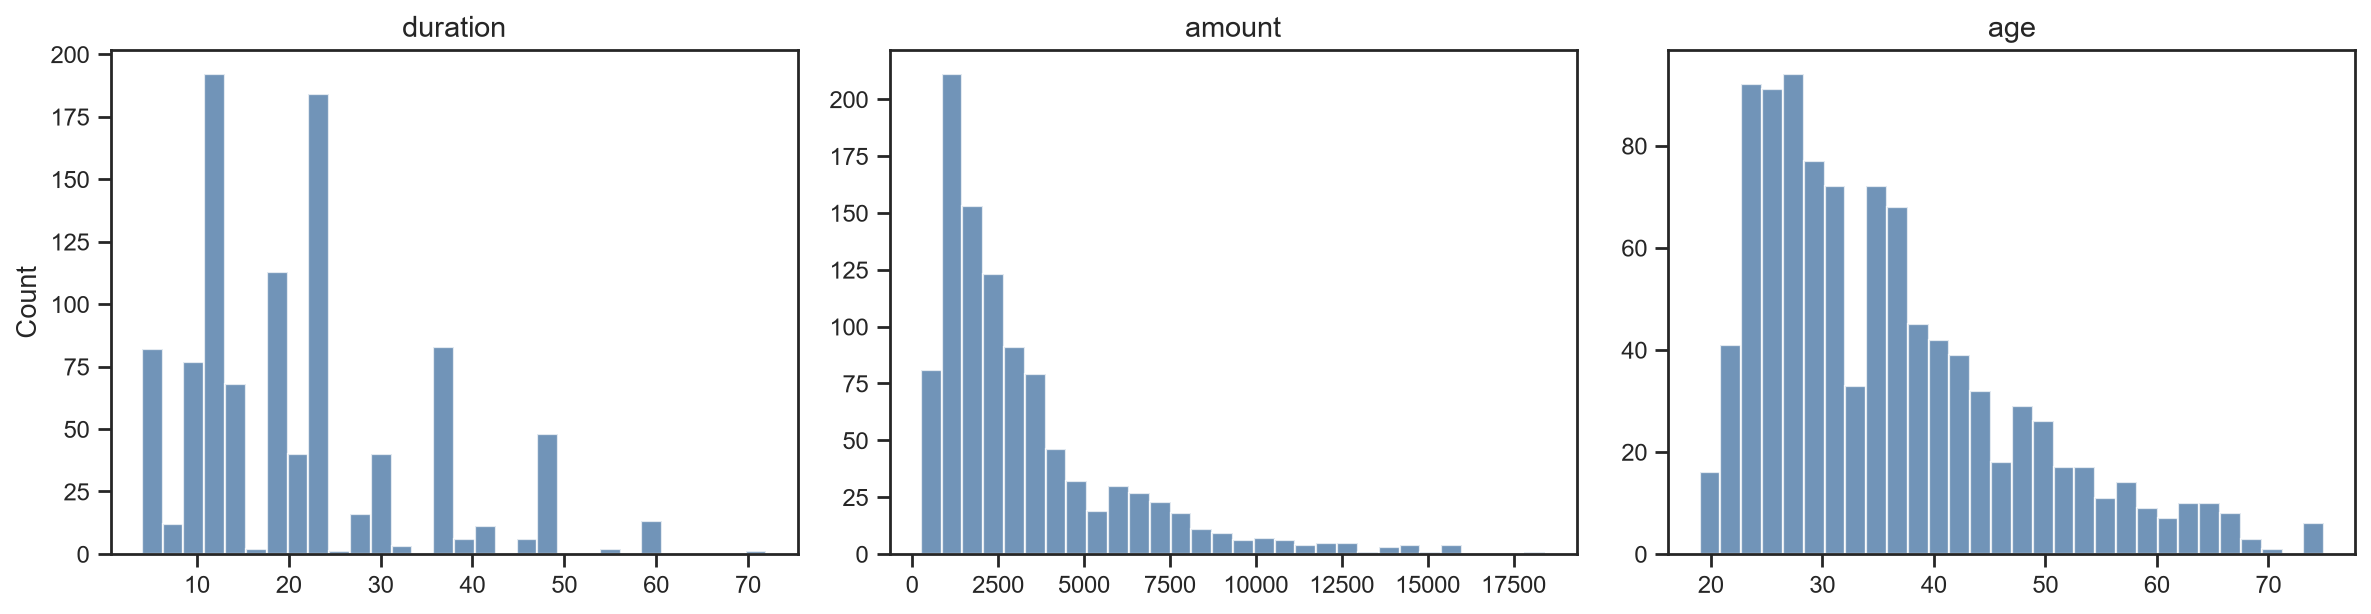

In [17]:
fig, axes = plt.subplots(1, len(continuous), figsize=(5 * len(continuous), 4))
for i, col in enumerate(continuous):
    axes[i].hist(data[col], bins=30, color=colours[0], edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=13)
    axes[i].set_ylabel('Count' if i == 0 else '')
plt.tight_layout()
plt.show()

**Key questions:**
* Are any features heavily skewed? How might that affect modelling?
* Which continuous features appeared highest in the MI ranking?

**Default rates by top categorical features**

The plots below show default rates across categories for the features that MI identified as most relevant.

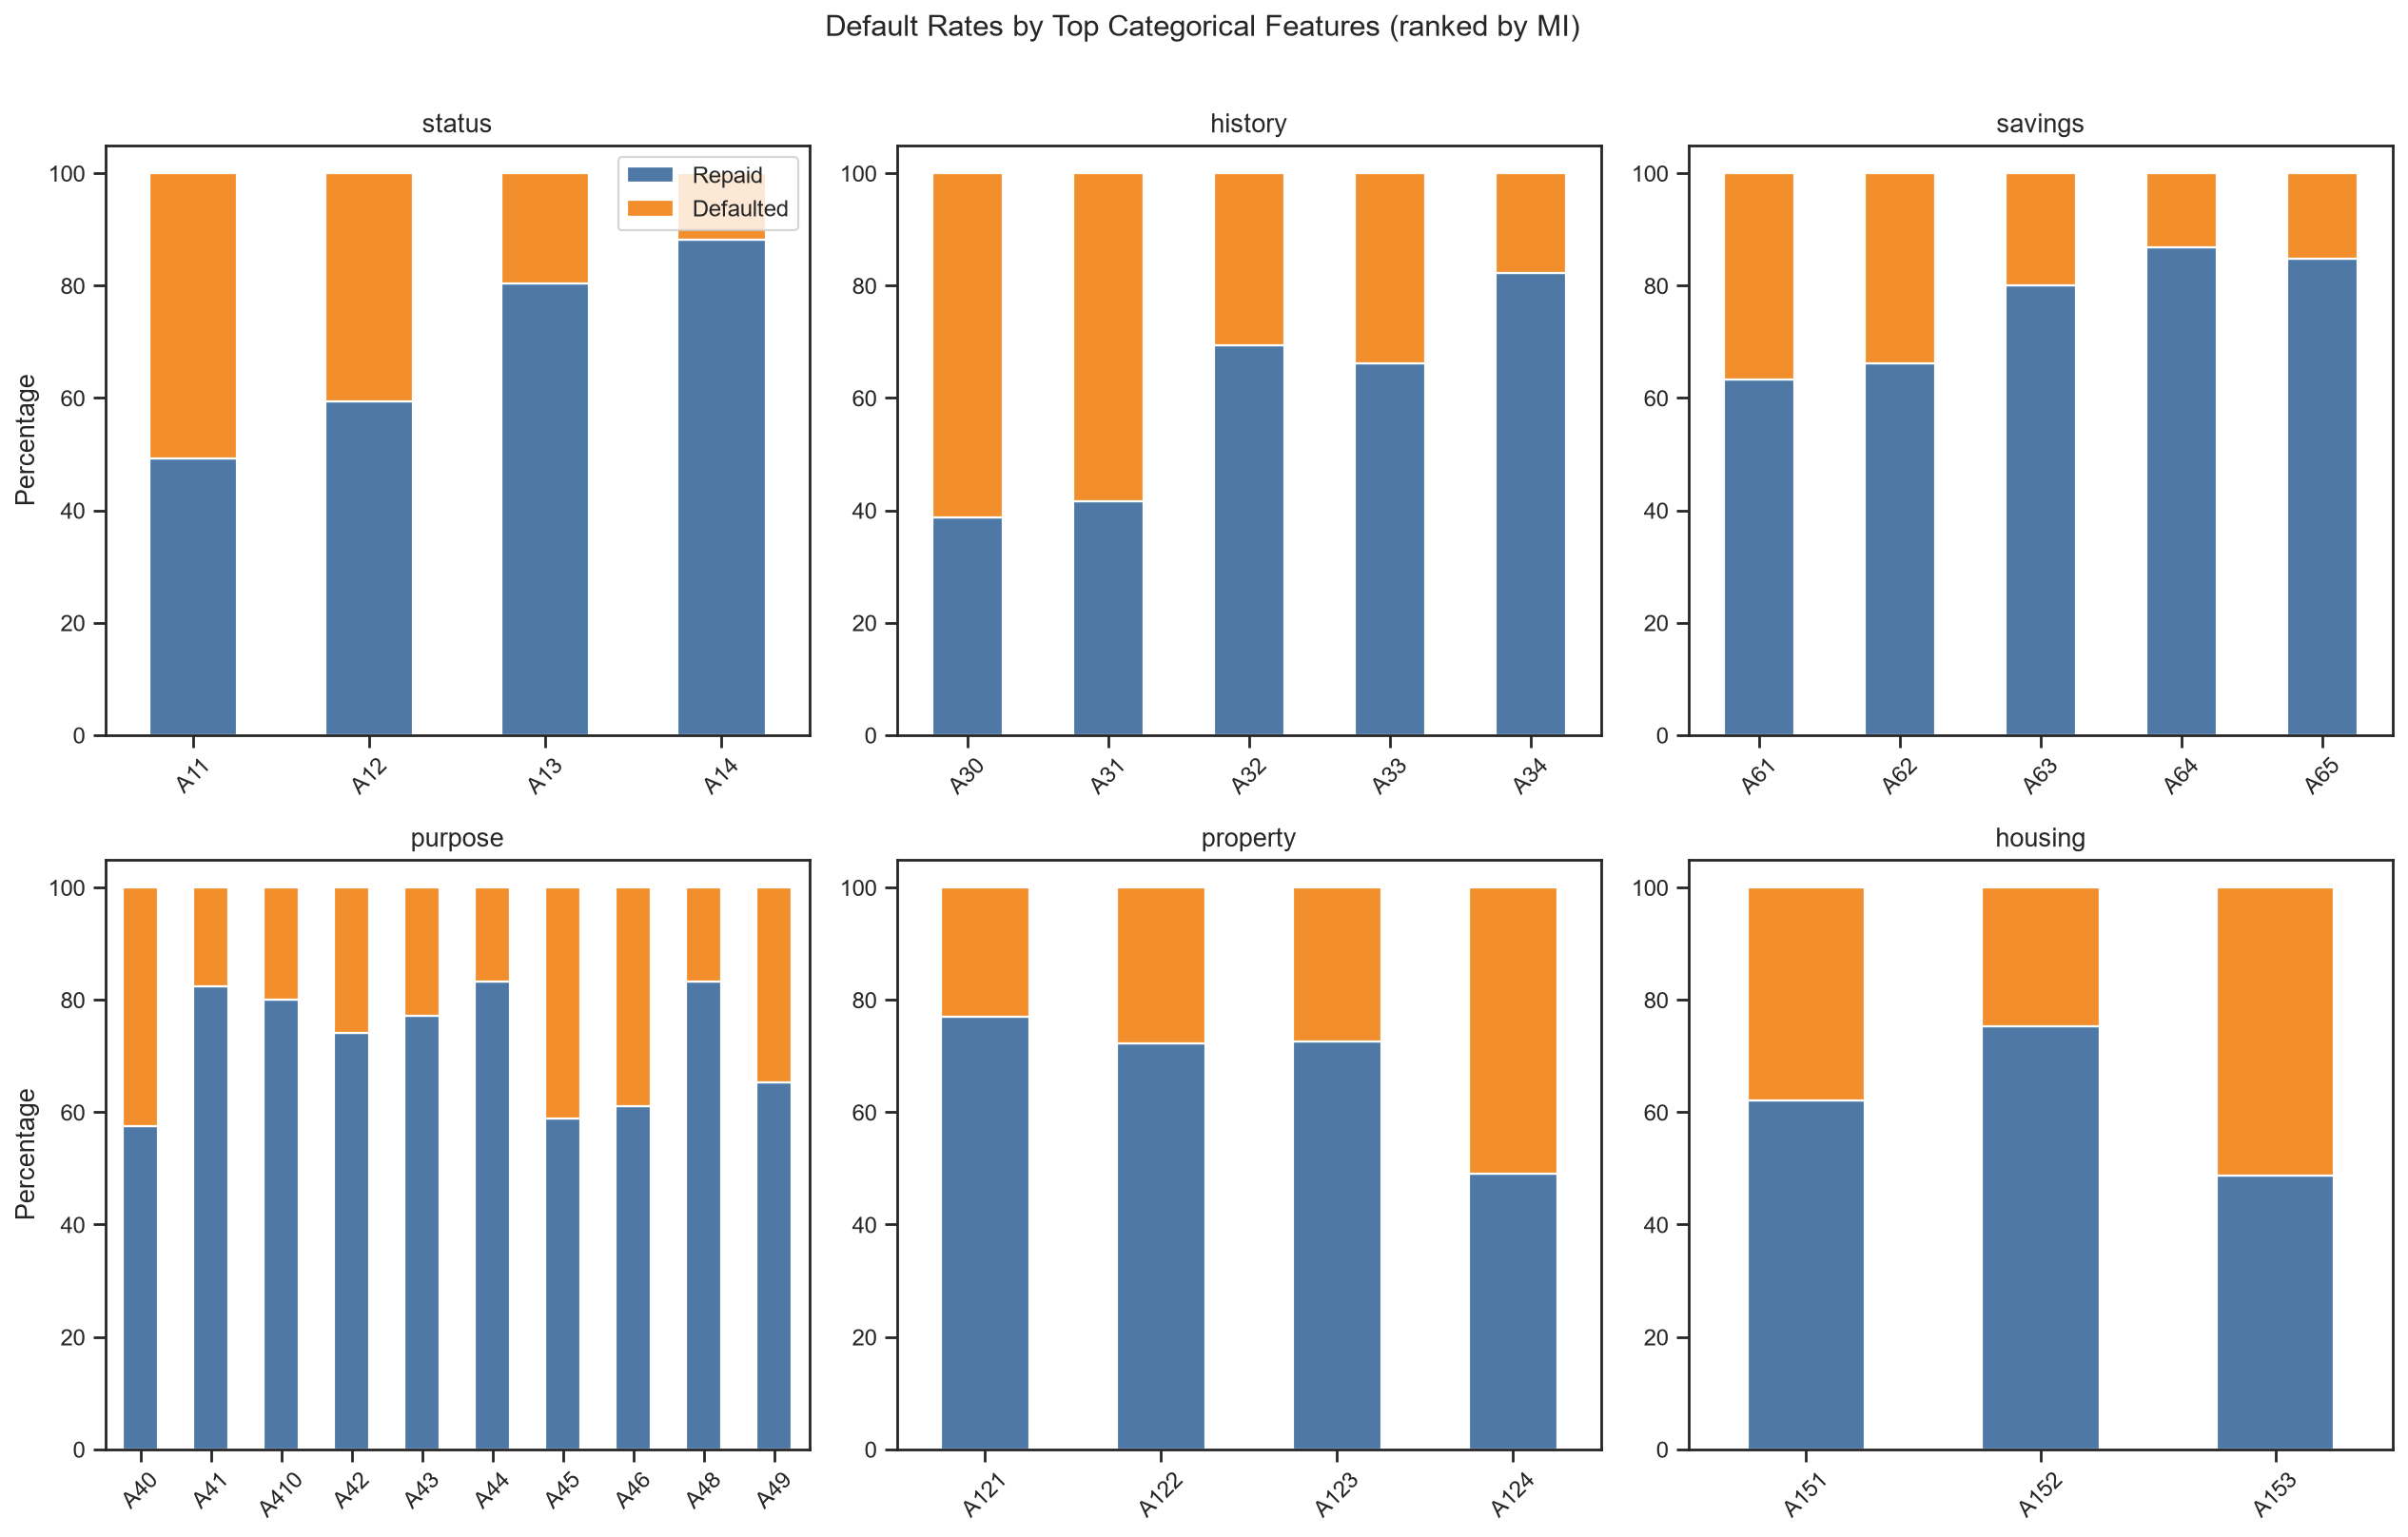

In [18]:
# Use the top categorical features from MI ranking
top_cat = mi_discrete.sort_values('MI', ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top_cat):
    ct = pd.crosstab(train[col], train['default'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=colours[:2], legend=False)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('Percentage' if i % 3 == 0 else '')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

axes[0].legend(['Repaid', 'Defaulted'], loc='upper right')
plt.suptitle('Default Rates by Top Categorical Features (ranked by MI)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Discussion:**
* Which categories show the largest differences in default rates?
* Do the cross-tab patterns confirm what the MI ranking suggested?
* Are there any features where the MI score is low but the default rate differences look large? What might explain this?

# 4. Representation design

A representation is the data the model sees. This section prepares the data for modelling: transforming skewed variables, encoding categoricals, and scaling numerical features. 

## 4.1 Log transformation of skewed numerical inputs

In [19]:
skewed_features = ['amount', 'age']

train[skewed_features] = train[skewed_features].apply(lambda x: np.log1p(x))
valid[skewed_features] = valid[skewed_features].apply(lambda x: np.log1p(x))

print('Log transformation applied to:', skewed_features)

Log transformation applied to: ['amount', 'age']


**Caution:** The above code overwrites columns in the training and validation sets. Any mistakes will require restarting from the data loading step.

**Question:** Why use a log transformation here? What representation design layer does this belong to?

## 4.2 Encoding categorical features

We use dummy encoding for categorical and discrete variables. This creates binary columns that models can process.

**Code: Dummy encoding**

In [20]:
encode_features = discrete + categorical

train = pd.get_dummies(train, columns=encode_features, drop_first=True)
valid = pd.get_dummies(valid, columns=encode_features, drop_first=True)

print(f'Dummy encoding applied. Training set now has {train.shape[1]} columns.')

Dummy encoding applied. Training set now has 55 columns.


## 4.3 Scaling numerical features

**Code: Standardisation**

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train[continuous] = scaler.fit_transform(train[continuous])
valid[continuous] = scaler.transform(valid[continuous])  # Use same scaling

print('Numerical features standardised:', continuous)

Numerical features standardised: ['duration', 'amount', 'age']


**Question:** Should the dummy variables be standardised too? Why or why not? (There is no single right answer.)

## 4.4 Finalising the training and validation datasets

In [22]:
predictors = [col for col in train.columns if col != 'default']

X_train, y_train = train[predictors], train['default']
X_valid, y_valid = valid[predictors], valid['default']

print(f'Final dataset ready: {len(predictors)} features.')

Final dataset ready: 54 features.


# 5. Model development

We need models that output **probability estimates** so we can apply the decision threshold from Section 1. Keep in mind: the models themselves are not the focus of this tutorial.

We follow the ladder from the lecture's *Improving the predictions* slide:

* **Logistic regression** (plain): the baseline you already know.
* **Keep the model, discipline it**: logistic regression with L2 (ridge) and L1 (lasso) regularisation, with the penalty strength chosen by cross-validation.
* **Change the recipe**: TabPFN-3, a tabular foundation model that is pretrained once and predicts on a new dataset in a single pass, with no per-dataset training.

## 5.1 Logistic regression


In [23]:
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(penalty=None)  # plain maximum likelihood, no regularisation
logit.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver beca

### Interpreting the coefficients

A key advantage of logistic regression is that its coefficients show how each feature affects the predicted log-odds of default.

**Code: Coefficient plot**

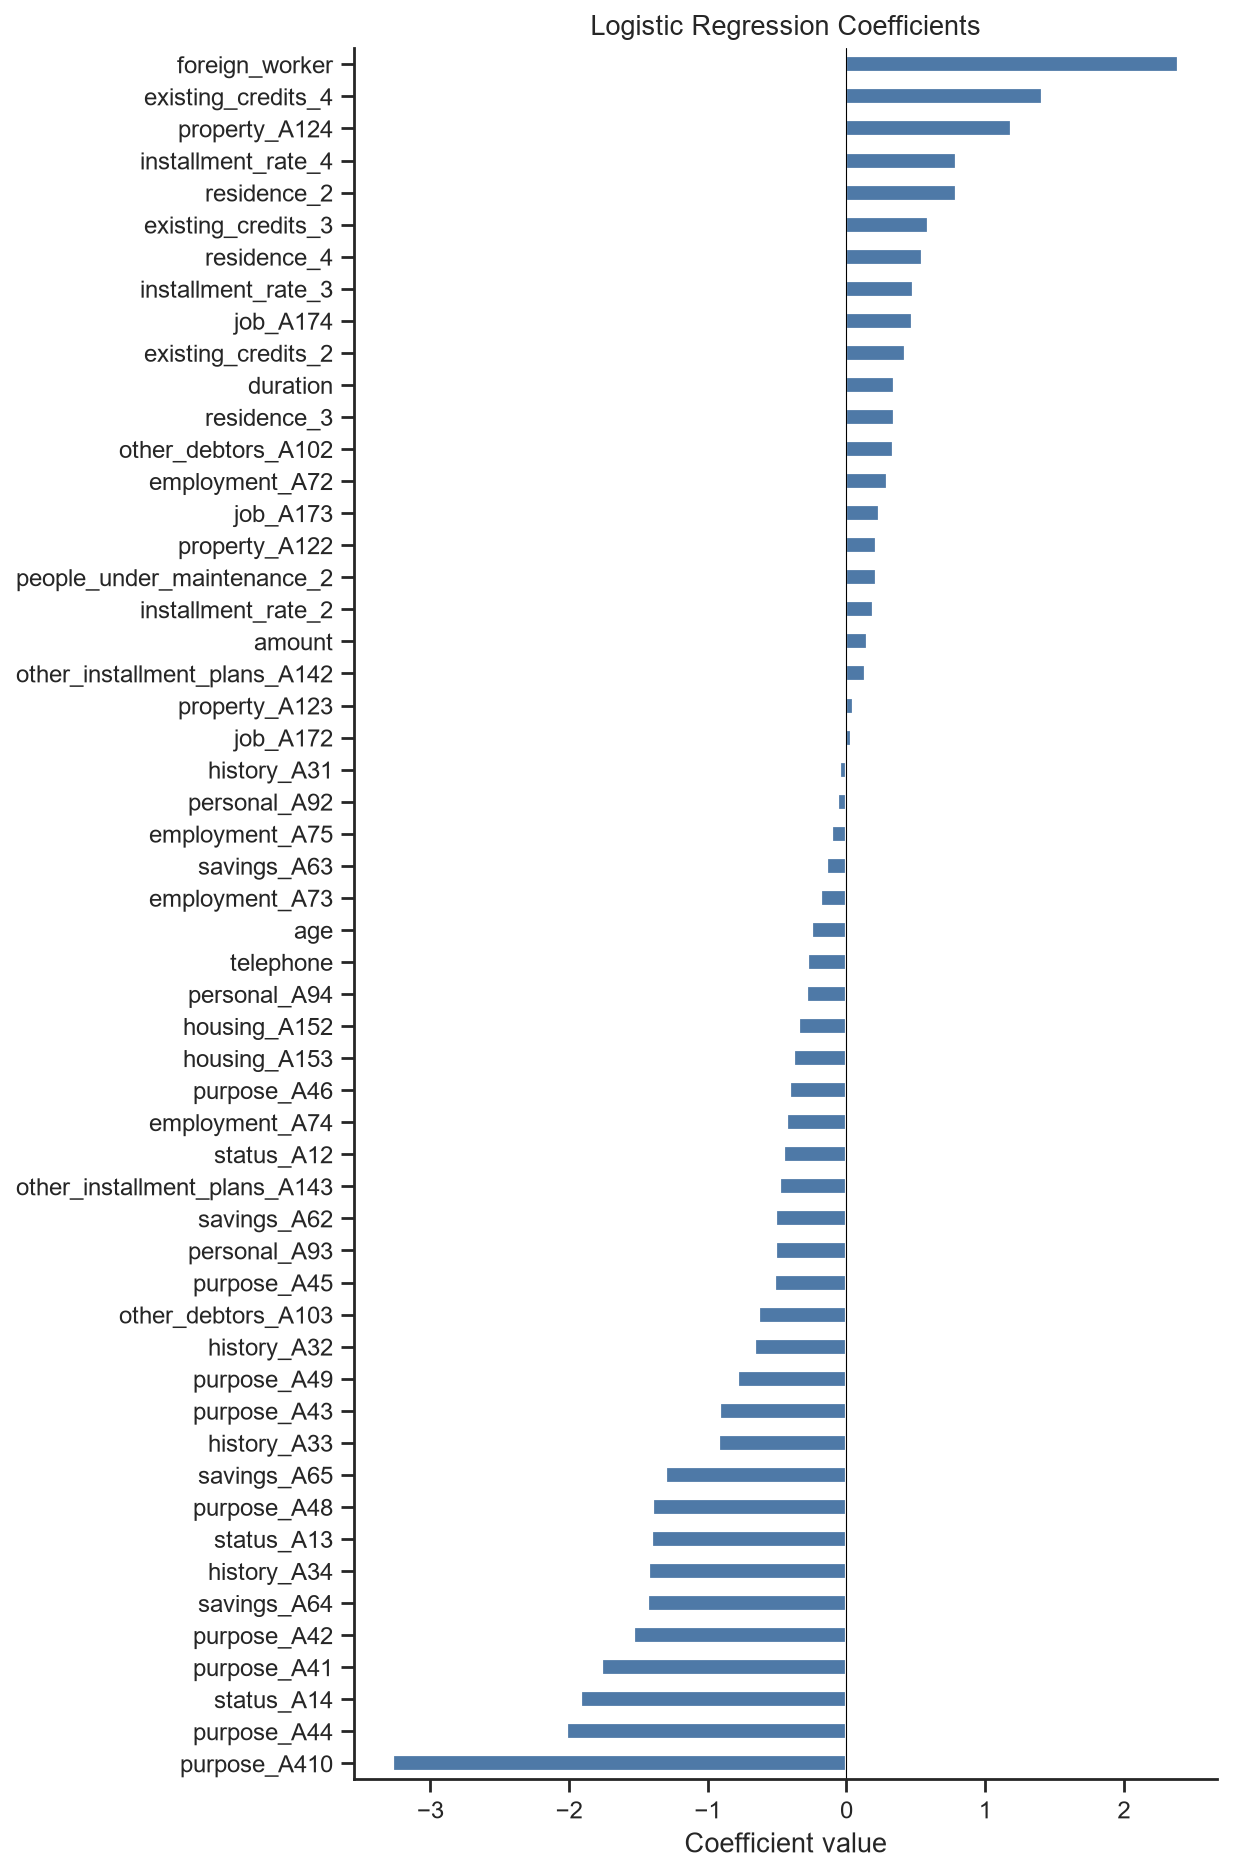

In [24]:
coefs = pd.Series(logit.coef_[0], index=predictors).sort_values()

fig, ax = plt.subplots(figsize=(8, max(6, len(predictors) * 0.22)))
coefs.plot(kind='barh', color=colours[0], ax=ax)
ax.set_xlabel('Coefficient value')
ax.set_title('Logistic Regression Coefficients')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
sns.despine()
plt.show()

**Discussion:**
* Which features increase vs. decrease the probability of default?
* Do the coefficients align with business intuition?

## 5.2 Regularised logistic regression

Regularisation is familiar from your earlier units: shrinking $\widehat{\beta}$ trades a little bias for lower variance. `LogisticRegressionCV` chooses the penalty strength by cross-validation on the training data.

Two details worth noticing:

* We set `scoring='neg_log_loss'`, so the cross-validation selects the penalty that gives the best **probability estimates**, not the best accuracy. Since our decisions consume probabilities, this is the right target. (The log loss is the negative log-likelihood). 
* The **L1** penalty can set coefficients exactly to zero, performing feature selection.


In [25]:
from sklearn.linear_model import LogisticRegressionCV

# L2 (ridge) logistic regression
logit_l2 = LogisticRegressionCV(penalty='l2', Cs=20, cv=5,
                                scoring='neg_log_loss', max_iter=5000)
logit_l2.fit(X_train, y_train)

# L1 (lasso) logistic regression
logit_l1 = LogisticRegressionCV(penalty='l1', solver='saga', Cs=20, cv=5,
                                scoring='neg_log_loss', max_iter=5000)
logit_l1.fit(X_train, y_train)

n_zero = int(np.sum(logit_l1.coef_[0] == 0))
print(f'Selected C (L2): {logit_l2.C_[0]:.4f}')
print(f'Selected C (L1): {logit_l1.C_[0]:.4f}')
print(f'L1 set {n_zero} of {len(predictors)} coefficients exactly to zero.')


Selected C (L2): 0.2336
Selected C (L1): 0.6158
L1 set 17 of 54 coefficients exactly to zero.


**Hands-on practice:** Which features does the L1 penalty remove? Compare them against the mutual information ranking from Section 3. Do the two views of feature relevance agree?


## 5.3 TabPFN-3: a tabular foundation model

abPFN-3 is a *tabular foundation model*: pretrained once on synthetic data drawn from a prior over datasets, it produces predictions for a new dataset in a single forward pass, with no per-dataset training and no hyperparameters to tune.

Two reasons it belongs here:

* **It is the current state of the art on small-to-medium tabular data**, and it works as a black box. You hand it the same `X_train, y_train` and call `predict_proba`, exactly as with any scikit-learn classifier. No tuning, no search.
* **We are using a tool ahead of understanding it, on purpose.** *Why* a pretrained network can do inference on a dataset it has never seen is the subject of the final lecture on foundation models. Using capable tools before you can derive them is a normal and healthy part of applied work; this unit will circle back and open the box.

There are two ways to run it. **Choose one** by setting the flag below.

* **Option A — local model** (`pip install tabpfn`): downloads the weights on first use (you will log in to PriorLabs and accept the licence). Our training set is small, so CPU is fine.
* **Option B — API** (`pip install tabpfn-client`): runs on PriorLabs' servers; you create a free account on first use. **Your data is sent to their cloud.** That is fine for this public dataset, but a real consideration in practice — a bank would not casually ship customer records to a third-party API.

**If an import cell errors, restart the kernel before retrying** — a failed import can leave the session in a bad state, and reinstalling is rarely the fix.


In [33]:
USE_TABPFN_API = False  # False: local model (Option A). True: API (Option B).
API_KEY = "tabpfn_sk_ZkR84RxC9jpQ7oYq4jQgoeKXB24S-eufgK5aygFmUVM"

if USE_TABPFN_API:
    # Option B: pip install tabpfn-client
    from tabpfn_client import TabPFNClassifier, set_access_token
    set_access_token(API_KEY)
else:
    # Option A: pip install tabpfn
    from tabpfn import TabPFNClassifier
    import os; os.environ["TABPFN_TOKEN"] = API_KEY

tabpfn = TabPFNClassifier()
tabpfn.fit(X_train, y_train)   # for TabPFN, 'fit' just stores the data; the work happens at prediction
print('TabPFN-3 ready.')


TabPFN-3 ready.


## 5.4 TabPFN-3 with thinking mode (optional, API only)

Thinking mode (TabPFN-3-Plus) applies additional inference-time computation to improve the predictions. Prior Labs recommends it for high-ROI use cases where small accuracy gains matter. It is available **only through the API**, and thinking-mode fits draw from a separate, smaller daily budget than regular API predictions, so run this cell once rather than repeatedly.

Set `RUN_THINKING = True` only if you are using the API and want to try it.

In [34]:
RUN_THINKING = False

if RUN_THINKING:
    from tabpfn_client import TabPFNClassifier as TabPFNClassifierAPI
    tabpfn_thinking = TabPFNClassifierAPI(thinking_effort='high', thinking_metric='log-loss')  # see docs.priorlabs.ai for options
    tabpfn_thinking.fit(X_train, y_train)
    print('TabPFN-3 (thinking) ready.')
else:
    tabpfn_thinking = None
    print('Skipping thinking mode.')


Skipping thinking mode.


# 6. From predictions to decisions

This is the core of the tutorial. We now apply the decision framework from the lecture: convert probability estimates into actions using the threshold, and evaluate the results.

## 6.1 Applying the decision threshold

We use logistic regression to illustrate the process, then compare all models.

In [35]:
# Predict probabilities on the validation set
y_prob_logit = logit.predict_proba(X_valid)[:, 1]

# Apply the decision threshold
y_pred_logit = (y_prob_logit > decision_threshold).astype(int)

# Translate to business action: approve if predicted default probability is below threshold
approve_logit = (y_prob_logit <= decision_threshold).astype(int)

print(f'Decision threshold: {decision_threshold:.3f}')
print(f'Loans approved: {approve_logit.sum()} out of {len(approve_logit)} ({approve_logit.mean()*100:.1f}%)')
print(f'Loans rejected: {(1 - approve_logit).sum()} ({(1 - approve_logit).mean()*100:.1f}%)')

Decision threshold: 0.167
Loans approved: 131 out of 300 (43.7%)
Loans rejected: 169 (56.3%)


**Pause and think:** Is the approval rate reasonable? What would happen if we changed the threshold?

## 6.2 The confusion matrix

The confusion matrix shows the four possible outcomes of our decisions. 

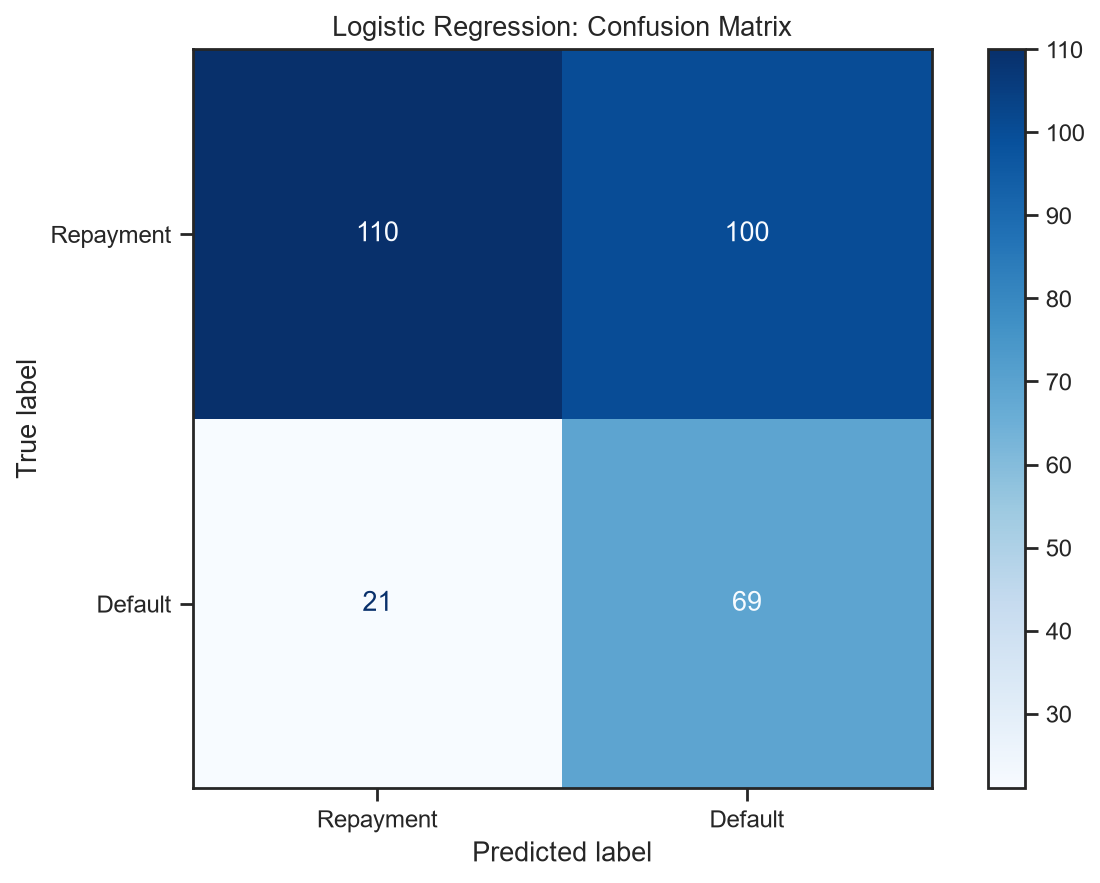

True Negatives (correctly approved):  110
False Positives (good borrowers rejected): 100
False Negatives (defaults approved):  21
True Positives (defaults caught):     69


In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_valid, y_pred_logit)
disp = ConfusionMatrixDisplay(cm, display_labels=['Repayment', 'Default'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression: Confusion Matrix')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives (correctly approved):  {tn}')
print(f'False Positives (good borrowers rejected): {fp}')
print(f'False Negatives (defaults approved):  {fn}')
print(f'True Positives (defaults caught):     {tp}')

## 6.3 Computing decision loss

The **decision loss** aggregates the costs from the loss matrix across all decisions. This is the primary evaluation metric for this tutorial, because it directly reflects business priorities.

In [37]:
def compute_decision_loss(y_true, y_pred, loss_fn, loss_fp):
    """Compute total and average decision loss."""
    y_true = np.ravel(y_true)
    fn_mask = (y_pred == 0) & (y_true == 1)  # Defaults that were approved
    fp_mask = (y_pred == 1) & (y_true == 0)  # Good borrowers that were rejected
    loss_per_case = loss_fn * fn_mask + loss_fp * fp_mask
    return loss_per_case.sum(), loss_per_case.mean()

total_loss, avg_loss = compute_decision_loss(y_valid, y_pred_logit, loss_fn, loss_fp)
print(f'Total decision loss: {total_loss:.0f}')
print(f'Average decision loss per loan: {avg_loss:.3f}')

Total decision loss: 410000
Average decision loss per loan: 1366.667


## 6.4 How does the threshold affect decisions?

The threshold is a business choice derived from the loss matrix. Changing the threshold shifts the balance between false positives and false negatives. The plot below shows how total decision loss varies with the threshold for the logistic regression model.

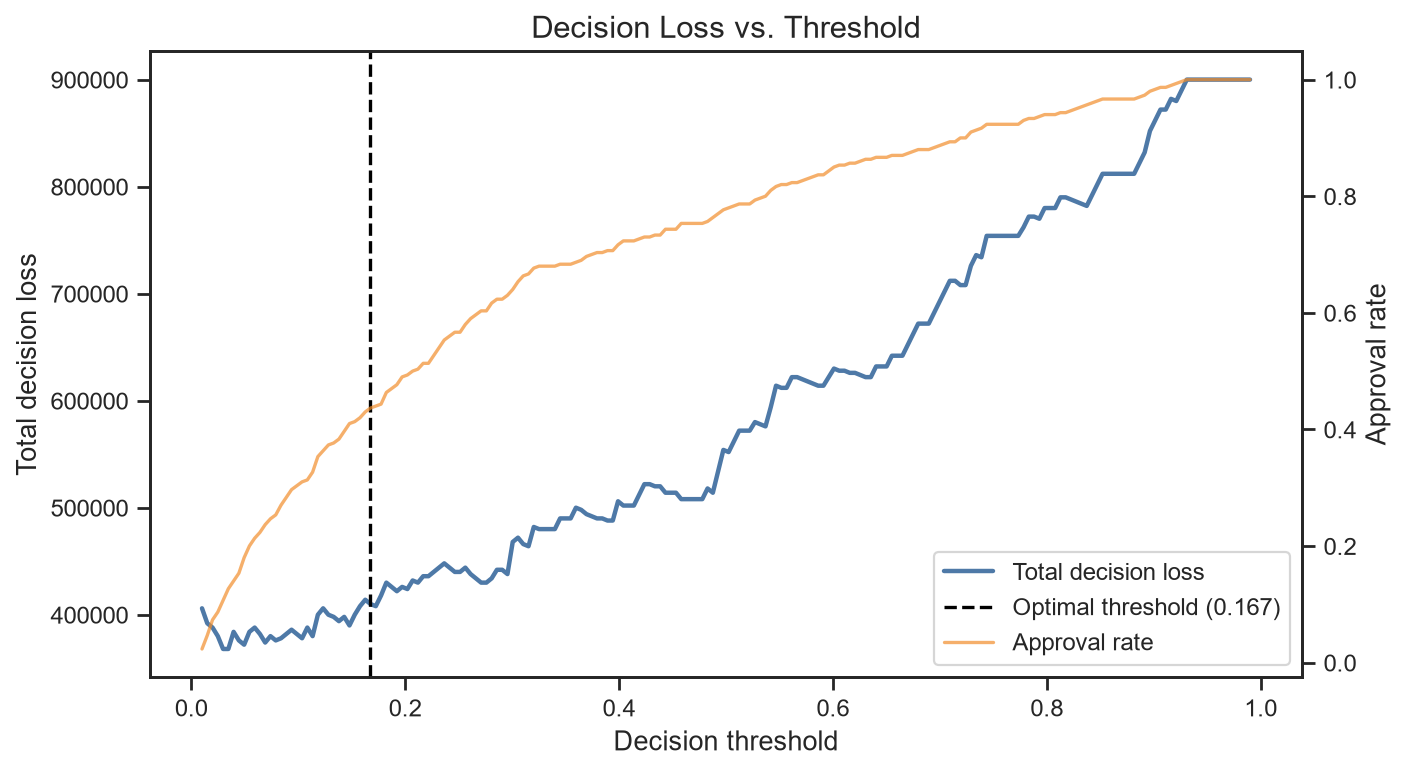

In [38]:
thresholds = np.linspace(0.01, 0.99, 200)
total_losses = []
approval_rates = []

for t in thresholds:
    y_pred_t = (y_prob_logit > t).astype(int)
    fn_mask = (y_pred_t == 0) & (np.ravel(y_valid) == 1)
    fp_mask = (y_pred_t == 1) & (np.ravel(y_valid) == 0)
    total_loss_t = (loss_fn * fn_mask + loss_fp * fp_mask).sum()
    total_losses.append(total_loss_t)
    approval_rates.append((y_pred_t == 0).mean())

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(thresholds, total_losses, color=colours[0], linewidth=2, label='Total decision loss')
ax1.axvline(decision_threshold, linestyle='--', linewidth=1.5, color='black',
            label=f'Optimal threshold ({decision_threshold:.3f})')
ax1.set_xlabel('Decision threshold', fontsize=12)
ax1.set_ylabel('Total decision loss', fontsize=12)
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
ax2.plot(thresholds, approval_rates, color=colours[1], linewidth=1.5, alpha=0.7, label='Approval rate')
ax2.set_ylabel('Approval rate', fontsize=12)
ax2.tick_params(axis='y')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.title('Decision Loss vs. Threshold', fontsize=14)
plt.tight_layout()
plt.show()

**Discussion:**
* Where is the decision loss minimised? Does it align with our calculated threshold?
* What happens to the approval rate as the threshold increases? What is the business implication?
* If the bank became more risk-averse (higher cost of approving a defaulter), how would the threshold and approval rate change?

**Why the empirical optimum differs from the theoretical threshold**:

The threshold formula assumes the model's predicted probabilities are *well-calibrated*: when the model outputs 0.20, approximately 20% of those applicants actually default. Logistic regression tends to push predicted probabilities toward the extremes, especially with a small training set. 

See Section 9 (optional).

# 7. Validation

Now we compare all four models using both decision loss and standard classification metrics.

## 7.1 Evaluation metrics

The table below summarises key metrics:

* **Decision loss**: Average cost per loan based on the loss matrix (lower is better). This is our primary metric.
* **Sensitivity (recall)**: Proportion of actual defaults correctly identified.
* **Specificity**: Proportion of repayments correctly classified.
* **Precision**: Among the rejected loans, what proportion actually defaulted?
* **AUC**: Ability to separate defaulters from non-defaulters across all possible thresholds (higher is better).
* **Cross-entropy**: How well the model predicts probabilities, not just binary decisions (lower is better).

## 7.2 Model evaluation function

In [39]:
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_score, log_loss

def evaluate_models(models, model_names, X_valid, y_valid, decision_threshold, loss_fn=1, loss_fp=1):
    """
    Evaluates multiple classification models on the validation set.

    Returns:
    - DataFrame with key metrics for each model.
    - Array of predicted probabilities for all models.
    """
    columns = ['Decision Loss', 'Std Err', 'Sensitivity', 'Specificity', 'Precision', 'AUC', 'Cross-entropy']
    results = pd.DataFrame(0.0, columns=columns, index=model_names)
    y_valid = np.ravel(y_valid)
    y_prob = np.zeros((len(y_valid), len(models)))

    for i, model in enumerate(models):
        y_prob[:, i] = model.predict_proba(X_valid)[:, 1]
        y_pred = (y_prob[:, i] > decision_threshold).astype(int)

        fn_mask = (y_pred == 0) & (y_valid == 1)
        fp_mask = (y_pred == 1) & (y_valid == 0)
        loss = loss_fn * fn_mask + loss_fp * fp_mask

        tn, fp, fn, tp = confusion_matrix(y_valid, y_pred).ravel()

        results.iloc[i, 0] = np.mean(loss)
        results.iloc[i, 1] = np.std(loss) / np.sqrt(len(y_valid))
        results.iloc[i, 2] = tp / (tp + fn)
        results.iloc[i, 3] = tn / (tn + fp)
        results.iloc[i, 4] = precision_score(y_valid, y_pred)
        results.iloc[i, 5] = roc_auc_score(y_valid, y_prob[:, i])
        results.iloc[i, 6] = log_loss(y_valid, y_prob[:, i])

    return results.round(3), y_prob

## 7.3 Model performance comparison

**Code: Computing validation results**

In [40]:
models = [logit, logit_l2, logit_l1, tabpfn]
model_names = ['Logistic', 'Logistic (L2)', 'Logistic (L1)', 'TabPFN-3']

if tabpfn_thinking is not None:
    models.append(tabpfn_thinking)
    model_names.append('TabPFN-3 (thinking)')

results, y_prob_all = evaluate_models(models, model_names, X_valid, y_valid,
                                       decision_threshold, loss_fn=loss_fn, loss_fp=loss_fp)

results['Decision Loss'] = results['Decision Loss'].astype(int)
results['Std Err'] = results['Std Err'].astype(int)

print('Model Performance Comparison:')
results


Model Performance Comparison:


,Decision Loss,Std Err,Sensitivity,Specificity,Precision,AUC,Cross-entropy
Logistic,1366,146,0.767,0.524,0.408,0.735,0.556
Logistic (L2),1180,114,0.878,0.419,0.393,0.764,0.513
Logistic (L1),1173,114,0.878,0.424,0.395,0.757,0.519
TabPFN-3,1066,110,0.889,0.476,0.421,0.780,0.500


**Key questions:**

* Which model achieves the lowest decision loss? Is the gap large relative to the standard error?
* Does regularisation help more with **discrimination** (AUC) or with **probability quality** (cross-entropy)? Why might cross-validating on log loss matter here?
* Where does TabPFN-3 stand out? Prior Labs' claim is that it produces *calibrated* predictive distributions in a single forward pass, a claim you can test directly in Section 9.1.

**Note:** decision loss is measured at a *single threshold*, so rankings can differ from AUC and cross-entropy, are threshold-free metrics. If two models swap places between the metrics, ask which property your decision actually consumes. Here, a calibrated probability near $\tau$.


# 8. Estimating business value

A predictive model is only valuable if it leads to **better business decisions**. In this section, we estimate the financial impact of using the best model compared to a baseline.

This follows the approach from the lecture: the value of a prediction system is the difference in total economic payoff between the new system and the baseline decision process.

## 8.1 Identifying the best model and baseline

From the results above, we identify the best-performing model (lowest decision loss) and use logistic regression as the baseline.

In [41]:
# Identify best model by decision loss
best_model_name = results['Decision Loss'].idxmin()
best_model_idx = model_names.index(best_model_name)
best_model = models[best_model_idx]

baseline_model = logit
baseline_name = 'Logistic Regression'

print(f'Best model: {best_model_name}')
print(f'Baseline: {baseline_name}')

Best model: TabPFN-3
Baseline: Logistic Regression


## 8.2 Confusion matrices: baseline vs. best model

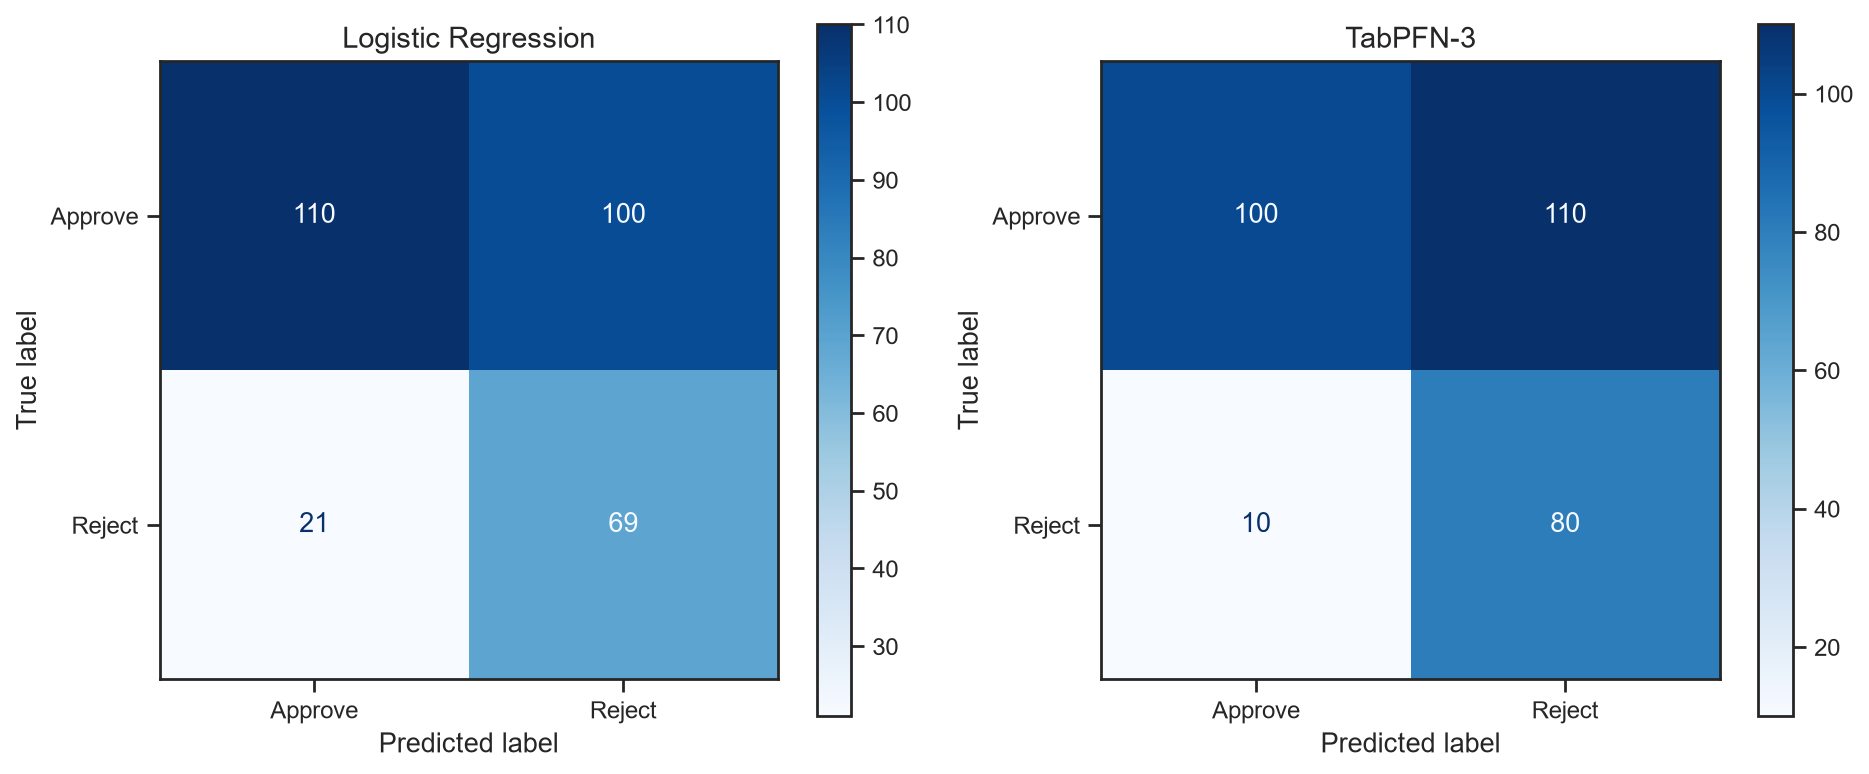

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, name in zip(axes, [baseline_model, best_model], [baseline_name, best_model_name]):
    y_pred = (model.predict_proba(X_valid)[:, 1] > decision_threshold).astype(int)
    cm = confusion_matrix(np.ravel(y_valid), y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Approve', 'Reject'])
    disp.plot(ax=ax, cmap='Blues')
    ax.set_title(name, fontsize=13)

plt.tight_layout()
plt.show()

## 8.3 Calculating business value

To translate model improvements into dollar values, we need assumptions about the bank's operations. The numbers below are illustrative.

| Variable | Definition | Example value |
|---|---|---|
| Total loans per year | Annual loan applications processed | 100,000 |
| Interest revenue per loan | Net interest earned on a performing loan | 4,000 |
| Loss given default | Average loss when a borrower defaults | 8,000 |
| Alternative return per rejection | Return from redeploying capital | 2,000 |

In [43]:
## Business assumptions
total_loans_per_year = 100_000
revenue_per_good_loan = 4_000   # Net interest revenue
loss_per_default = 8_000       # Loss given default
alt_return_per_rejection = 2_000  # Alternative return on rejected capital

# Confusion matrix components for each model (on validation set)
y_valid_arr = np.ravel(y_valid)

def get_cm_components(model):
    y_pred = (model.predict_proba(X_valid)[:, 1] > decision_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_valid_arr, y_pred).ravel()
    return tn, fp, fn, tp

# Compute rates (proportions) from validation set, then scale to annual volume
def annual_value(model, label):
    tn, fp, fn, tp = get_cm_components(model)
    n = len(y_valid_arr)

    # Scale to annual volume
    tn_annual = int(tn / n * total_loans_per_year)
    fp_annual = int(fp / n * total_loans_per_year)
    fn_annual = int(fn / n * total_loans_per_year)
    tp_annual = int(tp / n * total_loans_per_year)

    # Economic value
    value_approved_good = tn_annual * revenue_per_good_loan
    cost_approved_bad = fn_annual * loss_per_default
    value_rejected = (fp_annual + tp_annual) * alt_return_per_rejection

    total_value = value_approved_good - cost_approved_bad + value_rejected

    print(f'--- {label} ---')
    print(f'  Good loans approved:  {tn_annual:>8,}  x  ${revenue_per_good_loan:>8,}  =  ${value_approved_good:>14,}')
    print(f'  Defaults approved:    {fn_annual:>8,}  x -${loss_per_default:>8,}  = -${cost_approved_bad:>14,}')
    print(f'  All rejections:       {fp_annual + tp_annual:>8,}  x  ${alt_return_per_rejection:>8,}  =  ${value_rejected:>14,}')
    print(f'  Total annual value:                                    ${total_value:>14,}')
    print()
    return total_value

print('ESTIMATED ANNUAL BUSINESS VALUE')
print('=' * 70)
baseline_value = annual_value(baseline_model, baseline_name)
best_value = annual_value(best_model, best_model_name)

incremental = best_value - baseline_value
print(f'Incremental value of {best_model_name} over {baseline_name}:')
print(f'  ${incremental:>14,} per year')

ESTIMATED ANNUAL BUSINESS VALUE
--- Logistic Regression ---
  Good loans approved:    36,666  x  $   4,000  =  $   146,664,000
  Defaults approved:       7,000  x -$   8,000  = -$    56,000,000
  All rejections:         56,333  x  $   2,000  =  $   112,666,000
  Total annual value:                                    $   203,330,000

--- TabPFN-3 ---
  Good loans approved:    33,333  x  $   4,000  =  $   133,332,000
  Defaults approved:       3,333  x -$   8,000  = -$    26,664,000
  All rejections:         63,332  x  $   2,000  =  $   126,664,000
  Total annual value:                                    $   233,332,000

Incremental value of TabPFN-3 over Logistic Regression:
  $    30,002,000 per year


The numbers above are illustrative, but they demonstrate a key principle from the lecture: **even small improvements in predictive performance can translate into substantial business value at scale.**

Note that the true business impact should be measured using **economic profit**: the difference between loan returns and the alternative return on capital. This is exactly the payoff matrix logic from the lecture, applied at the portfolio level.

# 9. Probability calibration

**This section is optional further reading.** It connects probability quality to decision quality. 

In Section 6.4, we noted that the empirical loss-minimising threshold can differ from the theoretical threshold $\tau = 0.167$. The reason: the threshold formula assumes **well-calibrated probabilities**. When the model outputs 0.167, roughly 16.7% of those applicants should actually default.

If probabilities are miscalibrated, the threshold derived from the loss matrix no longer sits at the right point on the probability scale. **Calibration** addresses this directly: it adjusts a model's probability outputs so they match observed frequencies.


## 9.1 What does calibration look like?

A **calibration plot** (reliability diagram) groups predictions into bins by predicted probability, then plots the average predicted probability against the actual default rate in each bin. A perfectly calibrated model falls on the diagonal: predicted 30% means observed 30%.

But calibration is only half of the story: a model that predicts the base rate for every applicant is perfectly calibrated and perfectly useless. Good probabilistic predictions are **sharp** as well as calibrated. The aim is to maximise sharpness *subject to* calibration.

**Code: Calibration plots for all models**

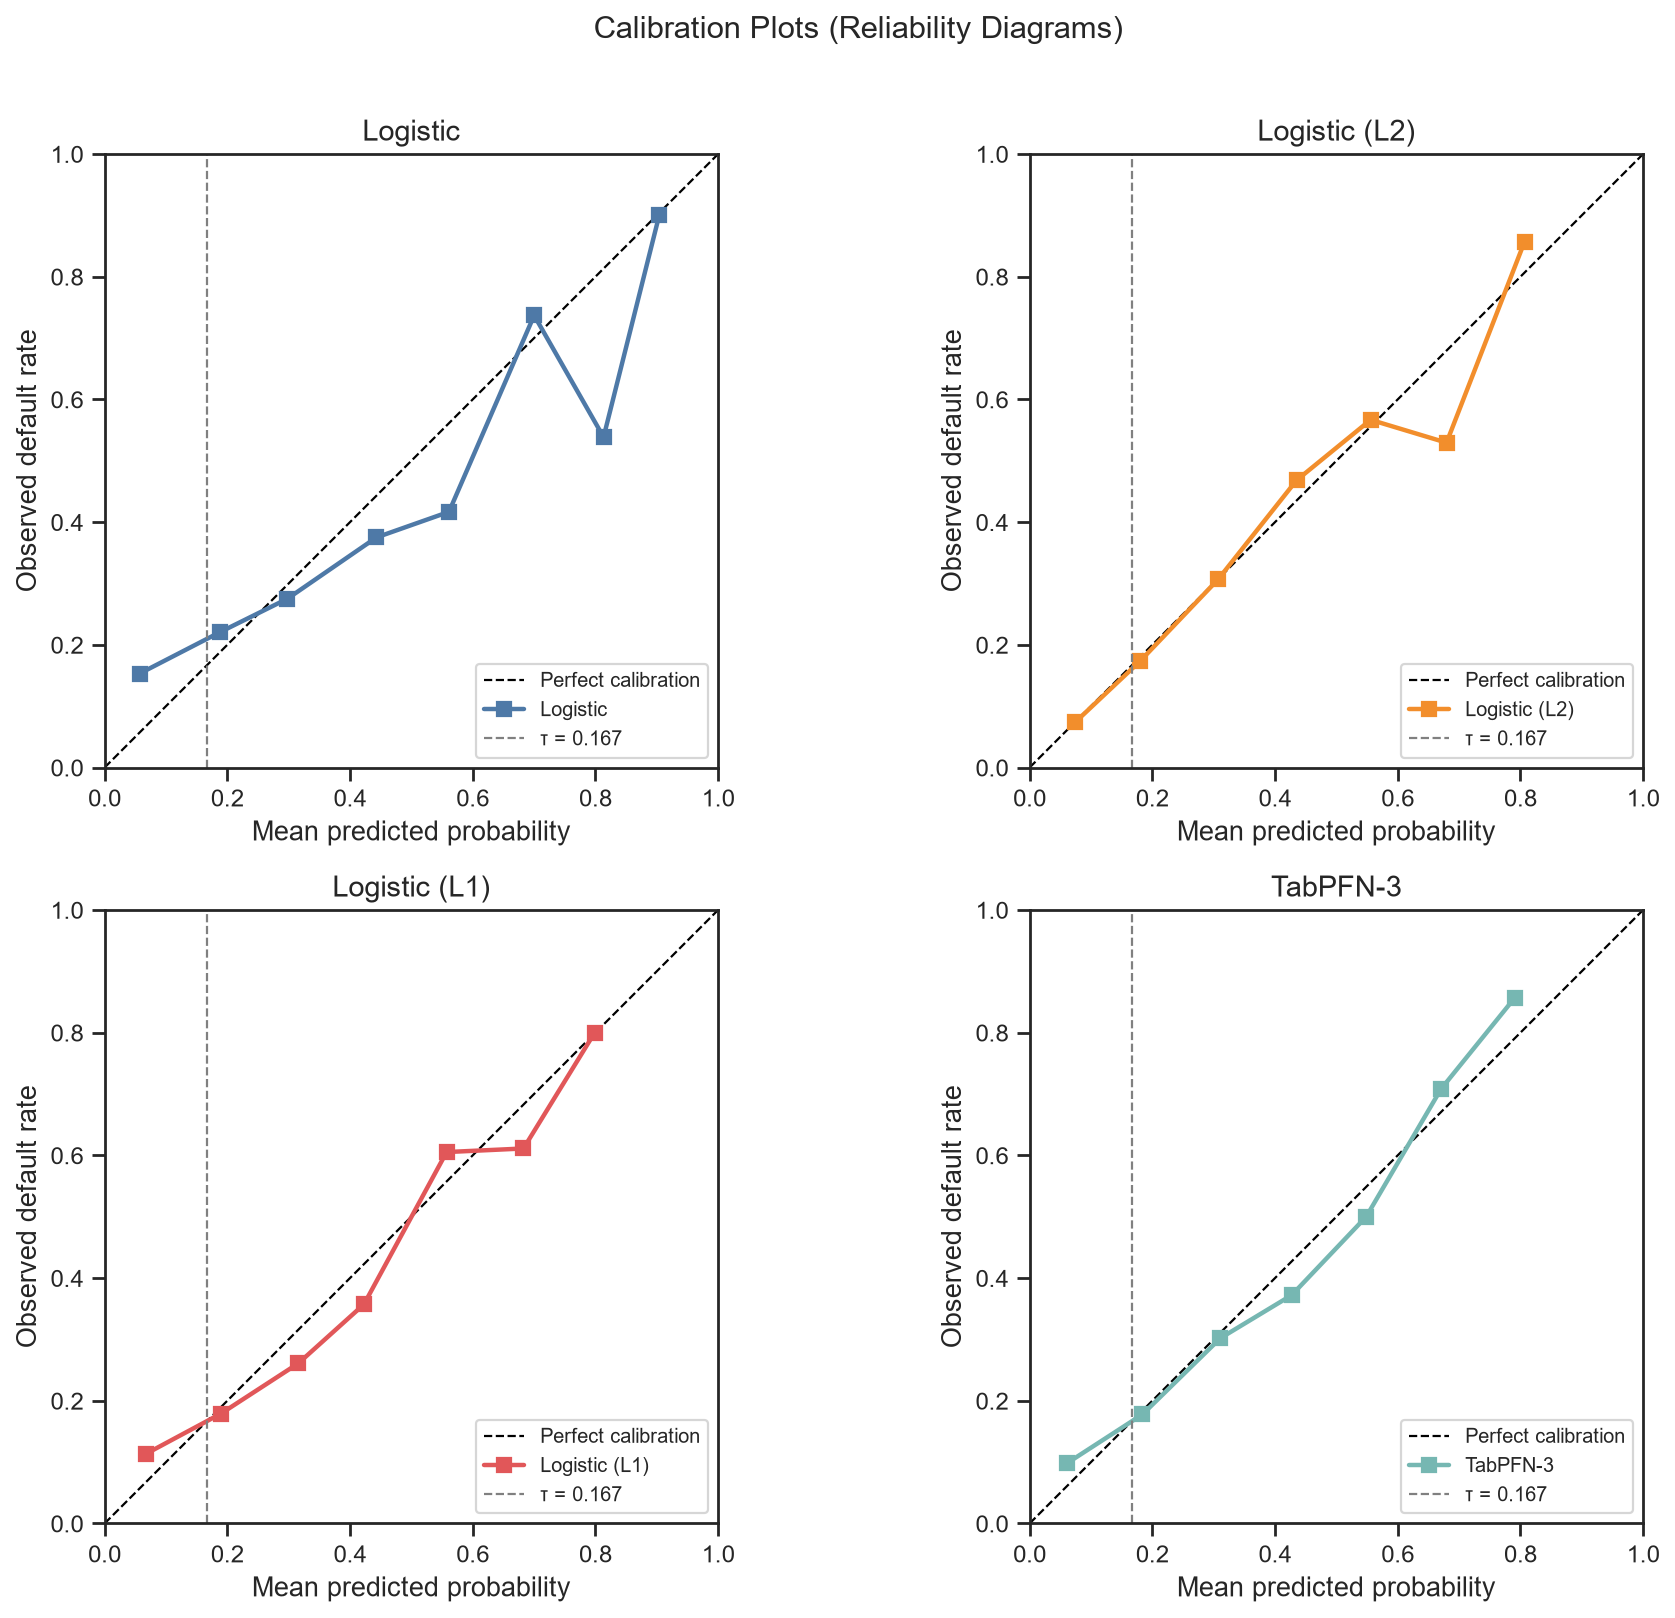

In [44]:
from sklearn.calibration import calibration_curve

n_models = len(models)
n_rows = (n_models + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 5 * n_rows))
axes = np.ravel(axes)
for ax in axes[n_models:]:
    ax.set_visible(False)  # hide any unused panel

for i, (name, model) in enumerate(zip(model_names, models)):
    y_prob = model.predict_proba(X_valid)[:, 1]
    prob_true, prob_pred = calibration_curve(np.ravel(y_valid), y_prob, n_bins=8, strategy='uniform')
    
    axes[i].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
    axes[i].plot(prob_pred, prob_true, 's-', color=colours[i], linewidth=2, markersize=6, label=name)
    axes[i].axvline(decision_threshold, color='grey', linestyle='--', linewidth=1, label=f'τ = {decision_threshold:.3f}')
    axes[i].set_xlabel('Mean predicted probability')
    axes[i].set_ylabel('Observed default rate')
    axes[i].set_title(name, fontsize=13)
    axes[i].legend(loc='lower right', fontsize=9)
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_aspect('equal')

plt.suptitle('Calibration Plots (Reliability Diagrams)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Reading the calibration plots:**

* Points **above** the diagonal mean the model underestimates the true default rate in that bin (overconfident about repayment).
* Points **below** the diagonal mean the model overestimates default risk (too pessimistic).
* A model can have strong **discrimination** (good AUC) but poor **calibration**. It ranks applicants correctly but assigns the wrong probability scale.

**Question:** Which models appear well-calibrated? Which are poorly calibrated, and in what direction?

## 9.2 Calibrating Logistic Regression with Platt scaling

**Platt scaling** fits a logistic regression on the model's predicted probabilities to produce better-calibrated outputs. Scikit-learn's `CalibratedClassifierCV` implements this using cross-validation on the training set to avoid overfitting the calibration to the same data.

We'll apply this to the logistic regression predictions.  Yes, this means we use a logistic regression to calibrate a logistic regression model!

**Code: Calibrate logistic regression and compare**

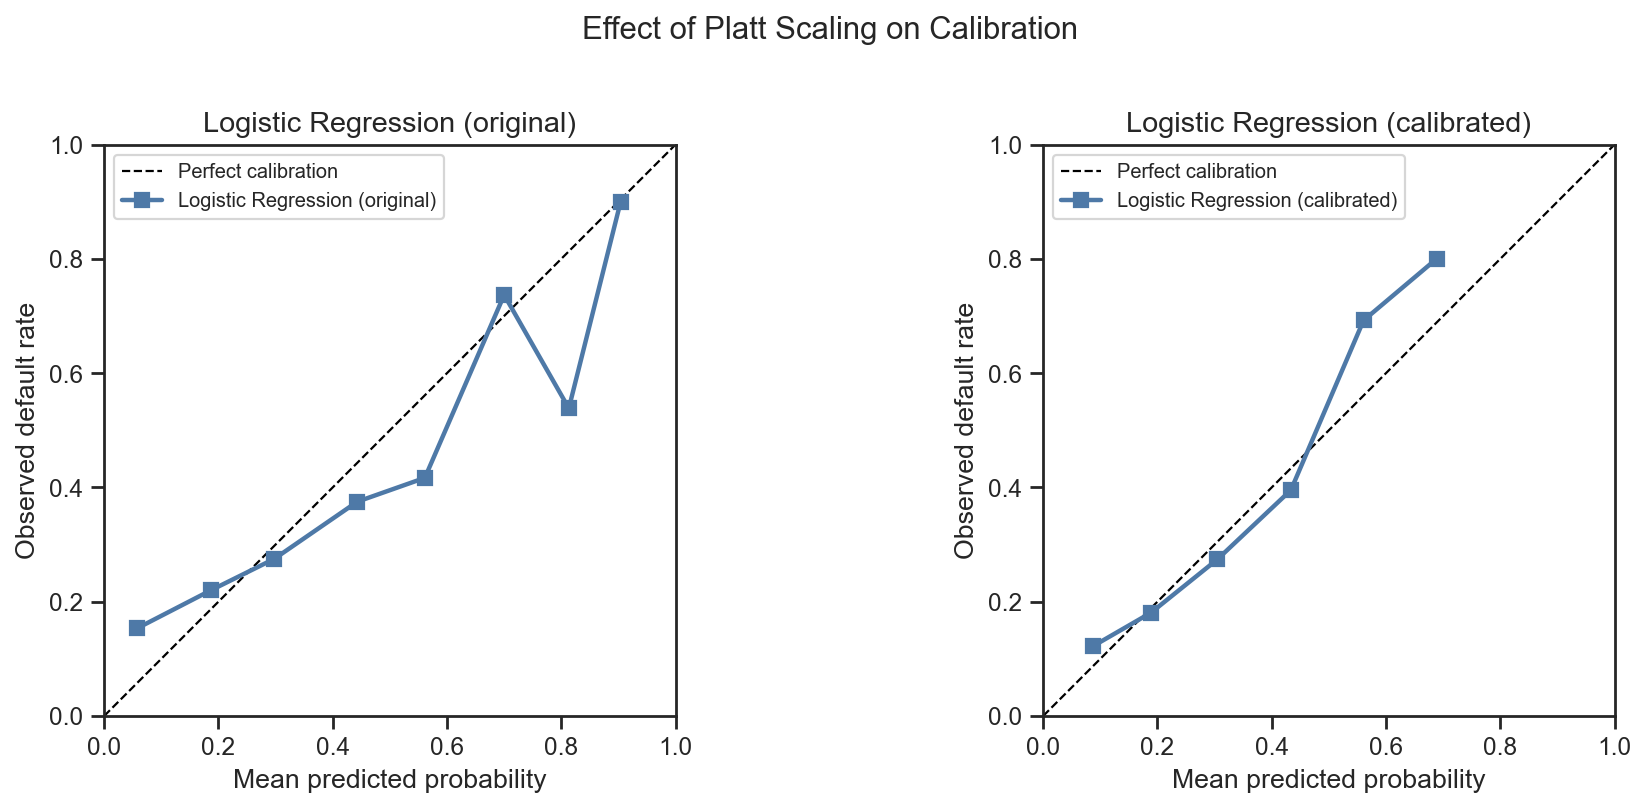

In [34]:
from sklearn.calibration import CalibratedClassifierCV

# Calibrate using Platt scaling (sigmoid)
calibrated = CalibratedClassifierCV(logit, method='sigmoid', cv=5)
calibrated.fit(X_train, y_train)

# Compare calibration curves: original vs. calibrated
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, label in zip(axes, [logit, calibrated], ['Logistic Regression (original)', 'Logistic Regression (calibrated)']):
    y_prob = model.predict_proba(X_valid)[:, 1]
    prob_true, prob_pred = calibration_curve(np.ravel(y_valid), y_prob, n_bins=8, strategy='uniform')
    
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
    ax.plot(prob_pred, prob_true, 's-', color=colours[0], linewidth=2, markersize=6, label=label)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Observed default rate')
    ax.set_title(label, fontsize=13)
    ax.legend(loc='upper left', fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')

plt.suptitle('Effect of Platt Scaling on Calibration', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 9.3 Does calibration improve decisions?

Better calibration means the predicted probabilities are more trustworthy. But does this actually reduce decision loss? Let's compare the original and calibrated models using our evaluation framework.

**Code: Compare original and calibrated predictions**

In [35]:
# Calibrate the logistic models using Platt scaling with cross-validation.
# Note: CalibratedClassifierCV refits the model on each fold. For TabPFN this
# means several refits (and, on the API, usage credits), so we calibrate only
# the logistic variants here. You can add TabPFN yourself if you are curious
# whether a foundation model needs post-hoc calibration at all.
from sklearn.calibration import CalibratedClassifierCV

models_to_calibrate = [logit, logit_l2, logit_l1]
names_to_calibrate = ['Logistic', 'Logistic (L2)', 'Logistic (L1)']

calibrated_models = []
for model in models_to_calibrate:
    cal_model = CalibratedClassifierCV(model, method='sigmoid', cv=10)
    cal_model.fit(X_train, y_train)
    calibrated_models.append(cal_model)

models_extended = models_to_calibrate + calibrated_models
names_extended = names_to_calibrate + [f'{n} (calibrated)' for n in names_to_calibrate]

results_cal, y_prob_cal = evaluate_models(models_extended, names_extended, X_valid, y_valid,
                                           decision_threshold, loss_fn=loss_fn, loss_fp=loss_fp)

results_cal['Decision Loss'] = results_cal['Decision Loss'].astype(int)
results_cal['Std Err'] = results_cal['Std Err'].astype(int)

print('Model Performance Comparison (original vs. calibrated):')
results_cal


Model Performance Comparison (original vs. calibrated):


,Decision Loss,Std Err,Sensitivity,Specificity,Precision,AUC,Cross-entropy
Logistic,1366,146,0.767,0.524,0.408,0.735,0.556
Logistic (L2),1180,114,0.878,0.419,0.393,0.764,0.513
Logistic (L1),1173,114,0.878,0.424,0.395,0.757,0.519
Logistic (calibrated),1253,109,0.889,0.343,0.367,0.735,0.530
Logistic (L2) (calibrated),1140,101,0.911,0.376,0.385,0.763,0.515
Logistic (L1) (calibrated),1153,101,0.911,0.367,0.381,0.757,0.520


**Note**: If a model is already well-calibrated, calibration methods might hurt performance by introducing additional variance.  

**Discussion:**

Did calibration improve each model's cross-entropy? Did it improve the decision loss?

# 10. Wrap-up

In this tutorial, you:

* **Constructed a decision framework** from a loss matrix and derived the optimal threshold.
* **Explored** real-world credit data and identified key risk factors.
* **Trained** a logistic regression, regularised variants, and a tabular foundation model.
* **Applied the decision threshold** to convert probability estimates into business decisions.
* **Analysed threshold sensitivity** and its impact on approval rates and decision loss.
* **Estimated the business value** of an improved model relative to a baseline.
* **Explored probability calibration** as a bridge between probability quality and decision quality.

### Reflection questions

* If you were presenting this analysis to bank executives, what would you emphasise?
* What assumptions did we make, and how might they affect real-world deployment?
* The bank only observes outcomes for approved loans. How does this affect the training data? (Recall the lecture's discussion of feedback and decision-based selection bias.)
* TabPFN-3 required no per-dataset training, yet it produced probability estimates. In what sense did it "estimate" anything? Hold that question. 
